### LSTM 

### Importing all the neccesary libraries

In [23]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import ast
from copy import deepcopy

### Organizing the data

In [24]:
weather_paths = {
    "dk": "hourly_data_Danmark_55.99775695800781_10.0052490234375.csv",
    "ring": "hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv",
    "silk": "hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv"
}
def load_and_merge(main_path, weather_paths):
    df_main = pd.read_csv(main_path)
    df_main["datetime"] = pd.to_datetime(df_main["datetime"])

    dfs = []
    for prefix, path in weather_paths.items():
        df = pd.read_csv(path)
        df["date"] = pd.to_datetime(df["date"])
        df = df.add_prefix(f"{prefix}_").rename(columns={f"{prefix}_date": "datetime"})
        dfs.append(df)

    df = df_main.copy()
    for d in dfs:
        df = df.merge(d, on="datetime", how="left")

    return df.sort_values("datetime")

def expand_json_column(df, col, prefix):
    df[col] = df[col].apply(ast.literal_eval)
    expanded = df[col].apply(pd.Series).add_prefix(prefix)
    return pd.concat([df.drop(columns=[col]), expanded], axis=1)


def basic_features(df, add_lags=True, extra_lags=None):
    df["hour"] = df["datetime"].dt.hour

    if add_lags:
        df["lag_1"] = df["value_spot"].shift(1)
        df["lag_2"] = df["value_spot"].shift(2)
        df["lag_24"] = df["value_spot"].shift(24)

    if extra_lags:
        for lag in extra_lags:
            df[f"lag_{lag}"] = df["value_spot"].shift(lag)

    df = df.ffill()


    cat_cols = [c for c in ["zone_prev", "zone"] if c in df.columns]
    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Expand structured columns
    for col, prefix in [("import", "import_"), ("export", "export_")]:
        if col in df.columns:
            df = expand_json_column(df, col, prefix)

    if "mix" in df.columns:
        df["mix"] = df["mix"].apply(ast.literal_eval)
        df = pd.concat([df.drop(columns=["mix"]), df["mix"].apply(pd.Series)], axis=1)

    if "flows" in df.columns:
        df = df.join(df["flows"].apply(pd.Series))

    df = df.fillna(0)

    drop_cols = [
        "emissionFactorType", "battery storage", "hydro storage",
        "flows", "unit_spot", "unit_total_load"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

    return df

### Transforming the data

In [ ]:
def add_time_features(df):
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["weekday_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

    return df

def create_targets(df, base_col, horizon, prefix):
    for i in range(1, horizon + 1):
        df[f"{prefix}_t+{i}"] = df[base_col].shift(-i)
    return df

def create_sequences(X, Y, seq_len, horizon):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - horizon):

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

### Doing train and test splits

In [26]:
def prepare_data(df, target_cols, drop_cols):
    hours = df["hour"].values
    print("before", len(df))
    df = df.drop(columns=["datetime"], errors="ignore").dropna()
    print("after", len(df))

    X = df.drop(columns=target_cols + drop_cols).values
    Y = df[target_cols].values

    hours = hours[-len(X):]

    split1 = int(0.7 * len(X))
    split2 = int(0.85 * len(X))

    return (
        X[:split1], X[split1:split2], X[split2:],
        Y[:split1], Y[split1:split2], Y[split2:],
        hours[:split1], hours[split1:split2], hours[split2:]
    )

def scale_data(X_train, X_val, X_test):
    scaler = StandardScaler()
    return (
        scaler.fit_transform(X_train),
        scaler.transform(X_val),
        scaler.transform(X_test),
        scaler
    )

### Making classes for dataset and model

In [27]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



class LSTMModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

### Training the model

In [28]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience):
    best_val = float("inf")
    best_weights = None
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                val_loss += criterion(model(Xb), yb).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train {train_loss:.2f} | Val {val_loss:.2f}")

        if val_loss < best_val:
            best_val = val_loss
            best_weights = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping")
                break

    if best_weights:
        model.load_state_dict(best_weights)

    return model, train_losses, val_losses, best_val

### Plotting helper

In [29]:
def split_predictions(preds, actuals, horizon, split_type="both"):
    if split_type == "both":
        price_pred = preds[:, :horizon]
        carbon_pred = preds[:, horizon:]
        price_true = actuals[:, :horizon]
        carbon_true = actuals[:, horizon:]
        return price_pred, carbon_pred, price_true, carbon_true

    elif split_type == "price":
        return preds, actuals

    elif split_type == "carbon":
        return preds, actuals

### Plotting results

In [30]:
def plot_losses(train_losses, val_losses, title="Loss"):
    plt.figure()
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.legend()
    plt.title(title)
    plt.show()

def plot_prediction(y_true, y_pred, idx=0, title="Forecast", label="Value"):
    plt.figure()
    plt.plot(y_true[idx], label=f"Actual {label}")
    plt.plot(y_pred[idx], label=f"Predicted {label}")
    plt.legend()
    plt.title(title)
    plt.show()

### Evaluating model

In [31]:
def evaluate_and_plot(preds, actuals, horizon, mode="both", idx=0):
    print("\nFINAL RESULTS")

    if mode == "both":
        price_pred, carbon_pred, price_true, carbon_true = split_predictions(
            preds, actuals, horizon, "both"
        )

        print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
        print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")

        plot_prediction(price_true, price_pred, idx, "Price Forecast", "Price")
        plot_prediction(carbon_true, carbon_pred, idx, "Carbon Forecast", "Carbon")

    elif mode == "price":
        print(f"Price MAE: {np.mean(np.abs(preds - actuals)):.2f}")
        plot_prediction(actuals, preds, idx, "Price Forecast", "Price")

    elif mode == "carbon":
        print(f"Carbon MAE: {np.mean(np.abs(preds - actuals)):.2f}")
        plot_prediction(actuals, preds, idx, "Carbon Forecast", "Carbon")

def get_predictions(model, loader):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            preds.append(model(Xb).numpy())
            actuals.append(yb.numpy())

    return np.vstack(preds), np.vstack(actuals)

### Joint model

In [ ]:
HORIZON = 24
SEQ_LEN = 48
EPOCHS = 100

df = load_and_merge("final_data.csv", weather_paths)
df = basic_features(df)
df = add_time_features(df)

df = create_targets(df, "value_spot", HORIZON, "price")
df = create_targets(df, "carbonIntensity", HORIZON, "carbon")

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON+1)] +
    [f"carbon_t+{i}" for i in range(1, HORIZON+1)]
)

X_train, X_val, X_test, Y_train, Y_val, Y_test, h_train, h_val, h_test = prepare_data(
    df, target_cols, ["hour", "day_of_week", "month"]
)

X_train, X_val, X_test, scaler = scale_data(X_train, X_val, X_test)

X_train, Y_train = create_sequences(X_train, Y_train, h_train, SEQ_LEN, HORIZON)
X_val, Y_val = create_sequences(X_val, Y_val, h_val, SEQ_LEN, HORIZON)
X_test, Y_test = create_sequences(X_test, Y_test, h_test, SEQ_LEN, HORIZON)

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)

print(X_train.shape)

model = LSTMModel(X_train.shape[2], output_dim=Y_train.shape[1])

model, train_losses, val_losses, best_val = train_model(
    model, train_loader, val_loader,
    nn.L1Loss(),
    torch.optim.Adam(model.parameters(), lr=0.001),
    EPOCHS,
    patience=15
)

preds, actuals = get_predictions(model, test_loader)

evaluate_and_plot(preds, actuals, HORIZON, mode="both", idx=200)
plot_losses(train_losses, val_losses)

before 52562
after 52538
(1530, 48, 75)
Epoch 1: Train 3566.30 | Val 517.85
Epoch 2: Train 3425.39 | Val 453.90
Epoch 3: Train 3030.15 | Val 336.01
Epoch 4: Train 2432.78 | Val 249.31
Epoch 5: Train 1907.70 | Val 287.39
Epoch 6: Train 1738.44 | Val 311.78
Epoch 7: Train 1713.46 | Val 306.72
Epoch 8: Train 1711.13 | Val 302.24
Epoch 9: Train 1709.79 | Val 302.36
Epoch 10: Train 1736.54 | Val 286.47
Epoch 11: Train 1764.47 | Val 305.72
Epoch 12: Train 1623.28 | Val 212.89
Epoch 13: Train 1431.18 | Val 205.76
Epoch 14: Train 1339.64 | Val 201.77
Epoch 15: Train 1290.05 | Val 205.55
Epoch 16: Train 1269.96 | Val 210.78
Epoch 17: Train 1251.07 | Val 209.54
Epoch 18: Train 1240.17 | Val 208.99
Epoch 19: Train 1229.60 | Val 210.21
Epoch 20: Train 1220.61 | Val 207.99
Epoch 21: Train 1214.54 | Val 208.98
Epoch 22: Train 1202.76 | Val 207.26
Epoch 23: Train 1194.22 | Val 205.92
Epoch 24: Train 1188.09 | Val 205.13
Epoch 25: Train 1180.31 | Val 204.13
Epoch 26: Train 1169.72 | Val 205.16
Epoch 2

KeyboardInterrupt: 

### Carbon only model

/var/folders/xw/j6c1c3514_l7lyj6wyc6l1rc0000gn/T/ipykernel_45111/2687232548.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


Epoch 1: Train 572896.87 | Val 47391.24
Epoch 2: Train 565117.28 | Val 44428.92
Epoch 3: Train 530538.52 | Val 37381.65
Epoch 4: Train 470371.83 | Val 27761.66
Epoch 5: Train 391401.12 | Val 17556.72
Epoch 6: Train 304302.81 | Val 9502.87
Epoch 7: Train 223119.33 | Val 5920.51
Epoch 8: Train 160382.28 | Val 7685.49
Epoch 9: Train 122479.00 | Val 13232.41
Early stopping

FINAL RESULTS
Carbon MAE: 68.18


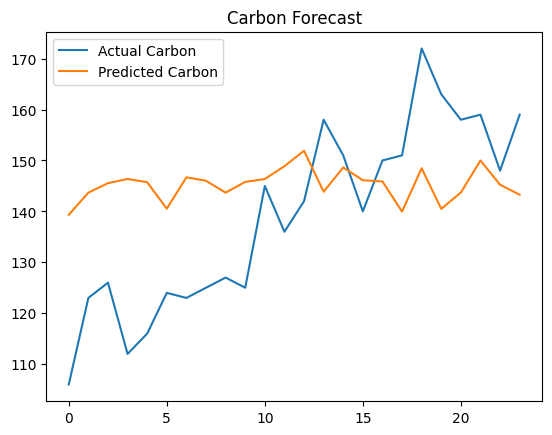

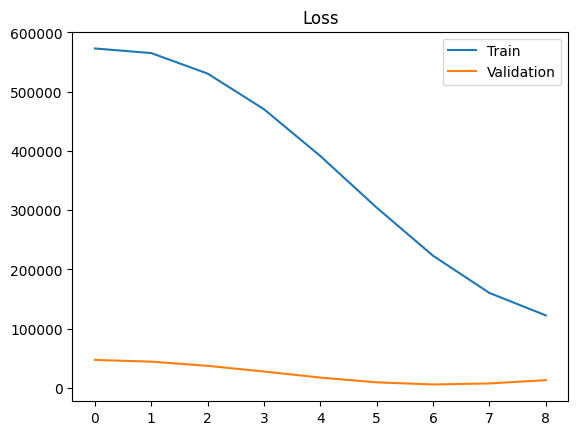

In [ ]:
HORIZON = 24
SEQ_LEN = 48
EPOCHS = 100

df = load_and_merge("final_data.csv", weather_paths)
df = basic_features(df)
df = add_time_features(df)

df = create_targets(df, "carbonIntensity", HORIZON, "carbon")

target_cols = [f"carbon_t+{i}" for i in range(1, HORIZON+1)]

X_train, X_val, X_test, Y_train, Y_val, Y_test, h_train, h_val, h_test = prepare_data(
    df, target_cols, ["hour", "day_of_week", "month"]
)

X_train, X_val, X_test, scaler = scale_data(X_train, X_val, X_test)

X_train, Y_train = create_sequences(X_train, Y_train, h_train, SEQ_LEN, HORIZON)
X_val, Y_val = create_sequences(X_val, Y_val, h_val, SEQ_LEN, HORIZON)
X_test, Y_test = create_sequences(X_test, Y_test, h_test, SEQ_LEN, HORIZON)

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)

model = LSTMModel(
    input_dim=X_train.shape[2],
    output_dim=Y_train.shape[1]   
)



model, train_losses, val_losses, best_val = train_model(
    model, train_loader, val_loader,
    nn.MSELoss(),
    torch.optim.Adam(model.parameters(), lr=0.001),
    EPOCHS,
    patience=2
)

preds, actuals = get_predictions(model, test_loader)

evaluate_and_plot(preds, actuals, HORIZON, mode="carbon", idx=200)
plot_losses(train_losses, val_losses)

### Price model for z1

/var/folders/xw/j6c1c3514_l7lyj6wyc6l1rc0000gn/T/ipykernel_45111/2687232548.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


Epoch 1: Train 1499.18 | Val 168.33
Epoch 2: Train 1497.08 | Val 167.22
Epoch 3: Train 1483.97 | Val 161.55
Epoch 4: Train 1445.75 | Val 151.66
Epoch 5: Train 1401.97 | Val 137.15
Epoch 6: Train 1320.41 | Val 119.28
Epoch 7: Train 1225.95 | Val 99.02
Epoch 8: Train 1119.40 | Val 78.70
Epoch 9: Train 998.93 | Val 66.30
Epoch 10: Train 887.55 | Val 75.26
Epoch 11: Train 820.40 | Val 100.50
Epoch 12: Train 790.54 | Val 123.79
Epoch 13: Train 785.30 | Val 139.50
Epoch 14: Train 777.40 | Val 147.02
Epoch 15: Train 778.69 | Val 146.31
Epoch 16: Train 783.37 | Val 142.21
Epoch 17: Train 775.24 | Val 139.02
Epoch 18: Train 771.08 | Val 137.34
Epoch 19: Train 776.09 | Val 136.42
Epoch 20: Train 775.40 | Val 136.11
Epoch 21: Train 772.43 | Val 138.27
Epoch 22: Train 774.41 | Val 137.83
Epoch 23: Train 773.46 | Val 137.54
Epoch 24: Train 777.57 | Val 135.65
Epoch 25: Train 775.81 | Val 136.56
Epoch 26: Train 773.37 | Val 138.28
Epoch 27: Train 772.86 | Val 138.27
Epoch 28: Train 773.78 | Val 139.

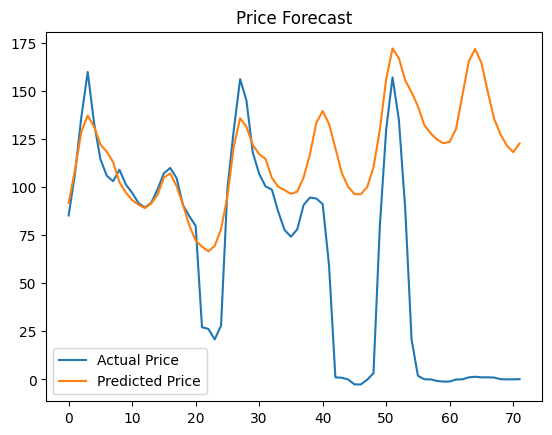

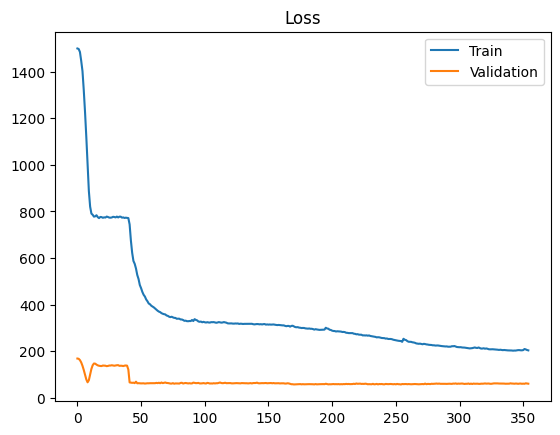

In [ ]:
HORIZON = 72
SEQ_LEN = 48
EPOCHS = 1000

df = load_and_merge("final_data.csv", weather_paths)

# zone filtering
df = df[df["zone"] == "DK-DK1"].copy()

df = basic_features(df, extra_lags=[168])
df["rolling_mean_24"] = df["value_spot"].rolling(24).mean()

df = add_time_features(df)

df = create_targets(df, "value_spot", HORIZON, "price")

target_cols = [f"price_t+{i}" for i in range(1, HORIZON+1)]

X_train, X_val, X_test, Y_train, Y_val, Y_test, h_train, h_val, h_test = prepare_data(
    df, target_cols, ["hour", "day_of_week", "month"]
)

X_train, X_val, X_test, scaler = scale_data(X_train, X_val, X_test)

X_train, Y_train = create_sequences(X_train, Y_train, h_train, SEQ_LEN, HORIZON)
X_val, Y_val = create_sequences(X_val, Y_val, h_val, SEQ_LEN, HORIZON)
X_test, Y_test = create_sequences(X_test, Y_test, h_test, SEQ_LEN, HORIZON)

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)

import LSTM_PRICE

model = LSTM_PRICE.LSTMModelPrice(
    input_dim=X_train.shape[2],
    HORIZON=HORIZON   
)
model, train_losses, val_losses, best_val = train_model(
    model, train_loader, val_loader,
    nn.L1Loss(),
    torch.optim.Adam(model.parameters(), lr=0.001),
    EPOCHS,
    patience=100
)

preds, actuals = get_predictions(model, test_loader)

evaluate_and_plot(preds, actuals, HORIZON, mode="price", idx=10)
plot_losses(train_losses, val_losses)

In [ ]:
# example_input = X_train[0:1]  # Shape (1, SEQ_LEN, num_features)
# print("Example input shape:", example_input.shape)
# print("Example input:", example_input)
# example_input_list = example_input.tolist()
# print("Example input as list:", example_input_list)

In [ ]:
# import pickle

# with open("lstm_model.pickle", "wb") as f:
#     pickle.dump({
#         "model_state": model.state_dict(),
#         "scaler": scaler,
#         "input_dim": X_train.shape[2],
#         "features": df_z1.drop(columns=target_cols + drop_cols).columns.tolist(),
#         "HORIZON": HORIZON,
#         "SEQ_LEN": SEQ_LEN,
#         "example_input": example_input_list
#     }, f)

In [ ]:
# with open("lstm_model.pickle", "rb") as f:
#     data = pickle.load(f)
#     print(data.keys())
